# Análise Exploratória — Desigualdade Regional no Cuidado ao Diabetes no SUS

Este notebook faz a EDA (análise exploratória de dados) da camada `gold`
(`data/gold/municipio_ano.csv`), gerada pelo notebook `01_ingestao_colab.ipynb`
no Google Colab. O objetivo aqui não é o índice ICVD (isso fica para
`03_indice_icvd.ipynb`), e sim descrever o panorama nacional, o efeito da
pandemia na série temporal, e as diferenças brutas entre regiões — a base
sobre a qual as conclusões qualitativas do projeto (`docs/04-conclusoes.md`)
serão escritas.

**Pré-requisito:** este notebook só roda depois que `data/gold/municipio_ano.csv`
existir localmente (etapa manual descrita na Seção 2.4 de
`01_ingestao_colab.ipynb`). Até lá, as células abaixo estão prontas mas não
foram executadas — não há saída de célula commitada neste notebook nem
imagem gerada em `docs/img/` a partir de dados fictícios.

As consultas agregadas usadas aqui vêm de `sql/consultas_duckdb.sql`, o
mesmo arquivo entregue nesta tarefa e validado isoladamente contra uma
tabela `gold` vazia.

## 1. Carga dos dados e das consultas

Abrimos o CSV da camada gold como uma *view* do DuckDB — não como uma
tabela materializada — porque a EDA só faz leitura: uma view evita duplicar
os dados na memória do processo enquanto ainda permite rodar SQL completo
sobre o CSV. `cod_municipio` é forçado para `VARCHAR` na leitura porque o
código IBGE tem zero à esquerda em alguns estados, e o DuckDB o inferiria
como inteiro por padrão, descartando esse zero.

A célula também roda a primeira consulta do arquivo `.sql` como um teste de
fumaça: se o arquivo não carregar ou a sintaxe estiver quebrada, falha aqui,
antes de qualquer gráfico.

In [1]:
import sys; sys.path.insert(0, '../src')
import duckdb, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

sns.set_theme(style='whitegrid')
con = duckdb.connect()
con.execute("""
    CREATE VIEW gold AS
    SELECT * FROM read_csv_auto('../data/gold/municipio_ano.csv',
                                types={'cod_municipio': 'VARCHAR'})
""")
con.execute(open('../sql/consultas_duckdb.sql').read().split(';')[0]).df()

,ano,internacoes,amputacoes,obitos,gasto_total,pct_amputacao,letalidade
0,2019,136276.0,9215.0,5755.0,1.081867e+08,6.76,4.22
1,2020,124646.0,9967.0,5862.0,1.069801e+08,8.00,4.70
2,2021,128088.0,10434.0,6045.0,1.123240e+08,8.15,4.72
3,2022,137325.0,10962.0,5937.0,1.342048e+08,7.98,4.32
4,2023,138316.0,11381.0,5360.0,1.440107e+08,8.23,3.88
5,2024,139598.0,11904.0,5257.0,1.535708e+08,8.53,3.77


Carregamos as cinco consultas de `sql/consultas_duckdb.sql` como uma lista de
strings, uma por posição (`consultas[0]` é a consulta 1, e assim por
diante). Isso evita duplicar o texto de cada SQL dentro do notebook: o
notebook reexecuta exatamente o que está versionado no arquivo `.sql`, em
vez de uma cópia que poderia divergir dele com o tempo.

In [2]:
consultas = [c.strip() for c in open('../sql/consultas_duckdb.sql').read().split(';') if c.strip()]
print(f'{len(consultas)} consultas carregadas de sql/consultas_duckdb.sql')

5 consultas carregadas de sql/consultas_duckdb.sql


## 2. Panorama nacional e efeito da pandemia

A consulta 1 dá o panorama anual: internações, amputações, óbitos, gasto
total do SUS, e as duas taxas derivadas (`pct_amputacao` e `letalidade`)
que também são dois dos quatro componentes do ICVD calculado no notebook
seguinte — aqui ainda em nível nacional, sem padronização por idade.

In [3]:
panorama = con.execute(consultas[0]).df()
panorama

,ano,internacoes,amputacoes,obitos,gasto_total,pct_amputacao,letalidade
0,2019,136276.0,9215.0,5755.0,1.081867e+08,6.76,4.22
1,2020,124646.0,9967.0,5862.0,1.069801e+08,8.00,4.70
2,2021,128088.0,10434.0,6045.0,1.123240e+08,8.15,4.72
3,2022,137325.0,10962.0,5937.0,1.342048e+08,7.98,4.32
4,2023,138316.0,11381.0,5360.0,1.440107e+08,8.23,3.88
5,2024,139598.0,11904.0,5257.0,1.535708e+08,8.53,3.77


A série temporal de internações por ano, com a faixa 2020–21 sombreada,
deixa visível o efeito da pandemia: internações eletivas e mesmo boa parte
das agudas por diabetes tendem a cair nesse período por menor procura e
por capacidade hospitalar redirecionada à COVID-19, e a leitura de
"melhora" nesses dois anos precisa considerar essa distorção antes de
qualquer conclusão sobre desigualdade regional.

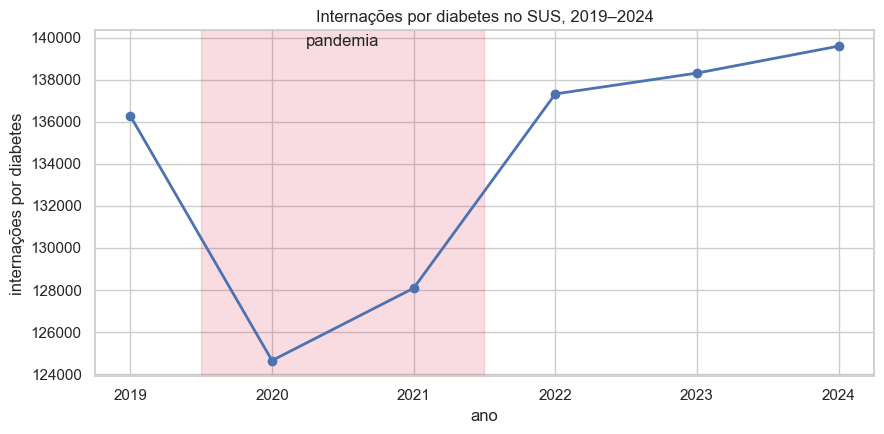

In [4]:
serie = con.execute("SELECT ano, SUM(internacoes) i FROM gold GROUP BY ano ORDER BY ano").df()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(serie['ano'], serie['i'], marker='o', linewidth=2)
ax.axvspan(2019.5, 2021.5, alpha=0.15, color='crimson')
ax.annotate('pandemia', xy=(2020.5, serie['i'].max()), ha='center')
ax.set_xlabel('ano'); ax.set_ylabel('internações por diabetes')
ax.set_title('Internações por diabetes no SUS, 2019–2024')
fig.tight_layout(); fig.savefig('../docs/img/serie_nacional.png', dpi=150)

## 3. Distribuição da taxa bruta municipal

Antes de olhar para regiões, vale ver a forma da distribuição no nível
mais fino: a taxa bruta de internação por 100 mil habitantes, por
município, somando todo o período 2019–2024. Essa taxa ainda não é
padronizada por idade (isso só acontece no notebook do ICVD) — é uma
primeira leitura da variabilidade entre os 5.570 municípios, sem qualquer
corte por volume de internações.

Trazemos a camada `gold` inteira para um `DataFrame` do pandas (`g`) aqui,
porque as próximas células fazem `groupby`/gráficos linha a linha
(histograma, boxplot, dispersão, correlação), o que é mais natural em
pandas + seaborn do que reescrever cada agregação em SQL.

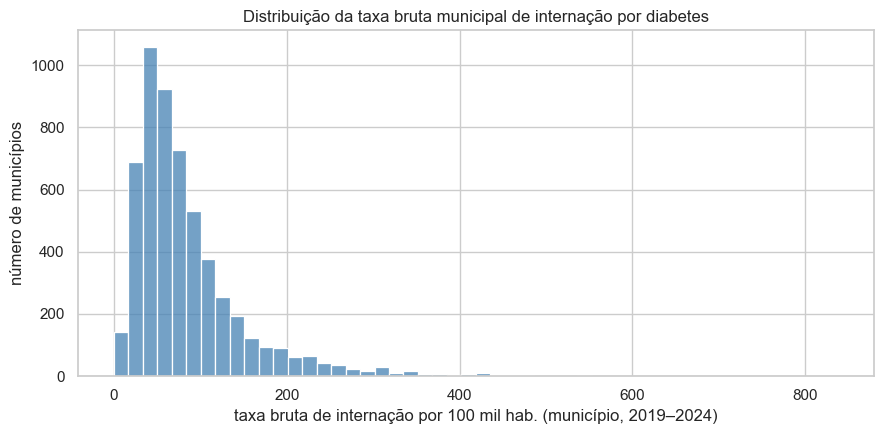

In [5]:
g = con.execute('SELECT * FROM gold').df()

municipal = (g.groupby(['cod_municipio', 'regiao'], as_index=False, observed=True)
              .agg(internacoes=('internacoes', 'sum'), populacao=('populacao', 'sum')))
municipal['taxa_bruta'] = 100000.0 * municipal['internacoes'] / municipal['populacao']

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(municipal['taxa_bruta'], bins=50, ax=ax, color='steelblue')
ax.set_xlabel('taxa bruta de internação por 100 mil hab. (município, 2019–2024)')
ax.set_ylabel('número de municípios')
ax.set_title('Distribuição da taxa bruta municipal de internação por diabetes')
fig.tight_layout(); fig.savefig('../docs/img/distribuicao_taxa_municipal.png', dpi=150)

## 4. Taxa por região, ano a ano

O boxplot usa a consulta 2 (taxa bruta por região e ano) para mostrar não só
a mediana de cada região, mas a dispersão ano a ano dentro dela — uma
região pode ter taxa média parecida com outra e ainda assim ser mais
instável de um ano para o outro.

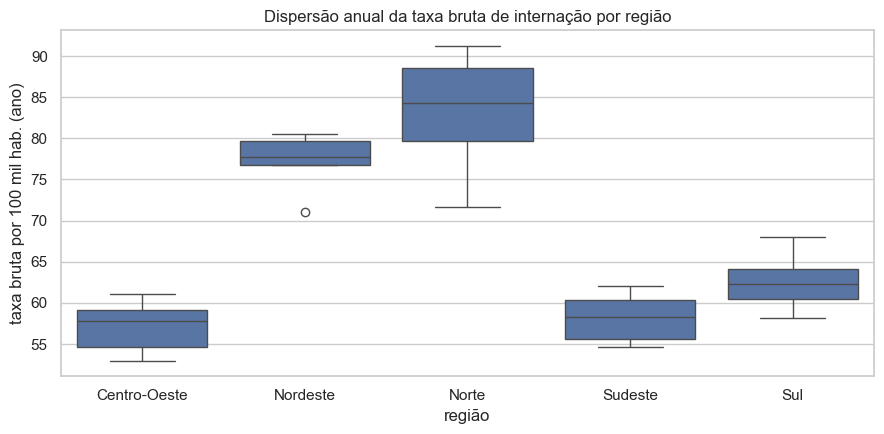

In [6]:
regional = con.execute(consultas[1]).df()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=regional, x='regiao', y='taxa_bruta', ax=ax)
ax.set_xlabel('região'); ax.set_ylabel('taxa bruta por 100 mil hab. (ano)')
ax.set_title('Dispersão anual da taxa bruta de internação por região')
fig.tight_layout(); fig.savefig('../docs/img/boxplot_taxa_regiao.png', dpi=150)

## 5. Antes, durante e depois da pandemia, por região

A consulta 3 quebra os seis anos em três blocos (2019 isolado; 2020-21, o
biênio de pandemia; 2022-24, a retomada) e cruza com região. O gráfico de
barras permite comparar não só o nível de cada região, mas se a queda e a
recuperação pós-pandemia foram parecidas entre elas — uma queda uniforme
sugere efeito de oferta de serviço; uma queda desigual sugere que a
pandemia acentuou a desigualdade regional que o projeto investiga.

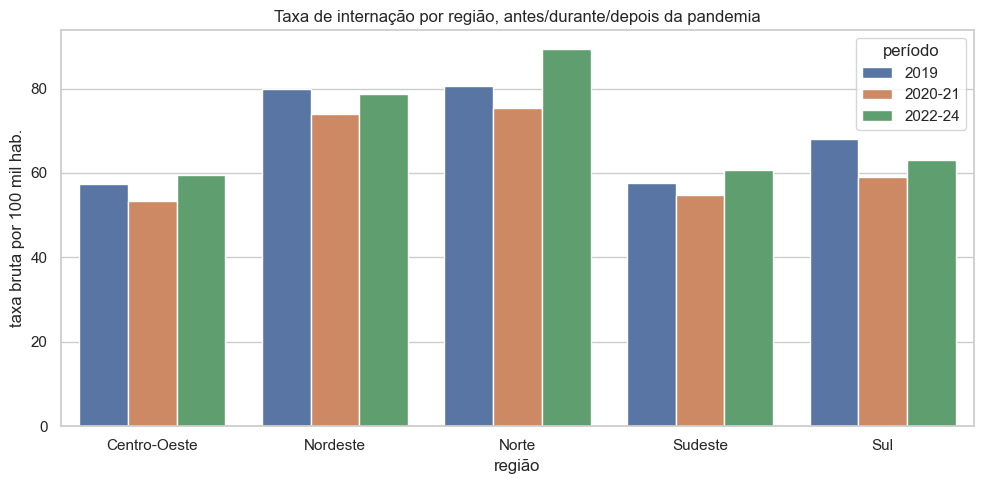

In [7]:
blocos = con.execute(consultas[2]).df()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=blocos, x='regiao', y='taxa_bruta', hue='bloco', ax=ax)
ax.set_xlabel('região'); ax.set_ylabel('taxa bruta por 100 mil hab.')
ax.set_title('Taxa de internação por região, antes/durante/depois da pandemia')
ax.legend(title='período')
fig.tight_layout(); fig.savefig('../docs/img/blocos_temporais_regiao.png', dpi=150)

## 6. Cobertura de Atencao Primaria x taxa de internacao

Hipotese de base do projeto: mais cobertura de Atencao Primaria a Saude (APS)
deveria estar associada a menos internacoes por diabetes, porque o cuidado
continuo evita a descompensacao que leva ao hospital.

**Atencao metodologica.** A cobertura vem de duas series com metodologias e
periodos disjuntos: `/cobertura/ab` ate 2020, truncada em 100%, e
`/cobertura/aps` de 2021 em diante, sem teto. Entre 2020 e 2021 a media dos
mesmos municipios salta 42,2 pontos percentuais, com correlacao de 0,506 — e
uma troca de regua, nao uma melhora do SUS. Por isso a cobertura **nao entra no
ICVD** e **nenhum grafico aqui mistura os dois blocos**: cada painel abaixo vive
dentro de uma unica metodologia, e a comparacao valida e a inclinacao dentro de
cada painel, nunca o deslocamento de um para o outro.


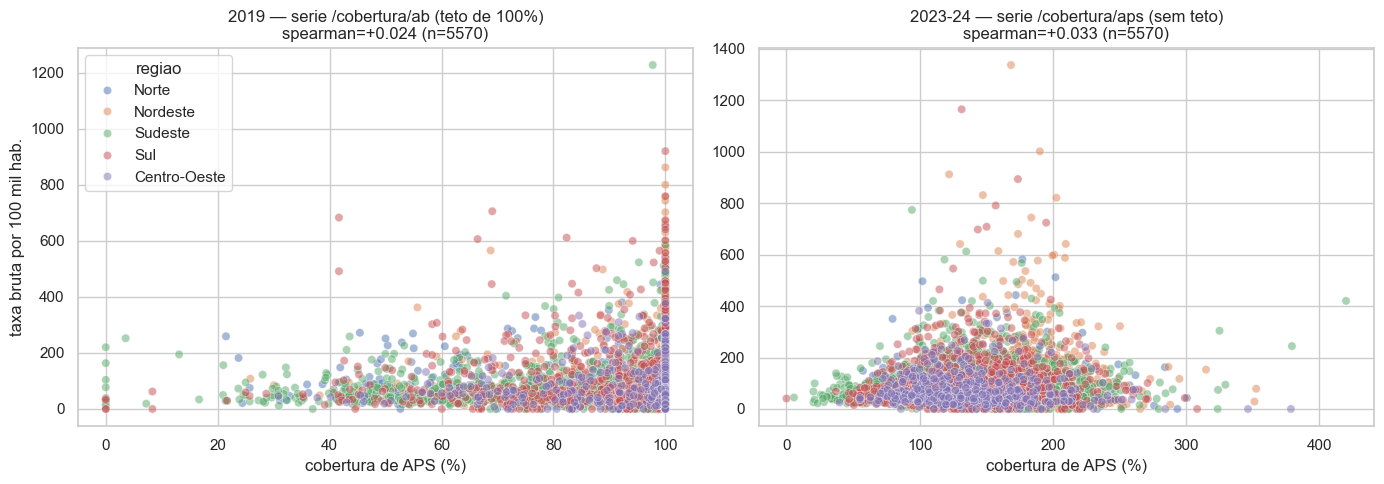

In [8]:
from scipy.stats import spearmanr

# Um painel por metodologia. 2019 vem da serie /cobertura/ab; 2023-24 da /aps.
BLOCOS = [('2019', [2019], 'serie /cobertura/ab (teto de 100%)'),
          ('2023-24', [2023, 2024], 'serie /cobertura/aps (sem teto)')]

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
for ax, (rotulo, anos, fonte) in zip(eixos, BLOCOS):
    bloco = (g[g['ano'].isin(anos)]
             .groupby(['cod_municipio', 'regiao'], as_index=False, observed=True)
             .agg(internacoes=('internacoes', 'sum'), populacao=('populacao', 'sum'),
                  cobertura_aps=('cobertura_aps', 'mean')))
    bloco['taxa_bruta'] = 100000.0 * bloco['internacoes'] / bloco['populacao']
    bloco = bloco.dropna(subset=['cobertura_aps', 'taxa_bruta'])

    sns.scatterplot(data=bloco, x='cobertura_aps', y='taxa_bruta', hue='regiao',
                    alpha=0.5, ax=ax, legend=(ax is eixos[0]))
    r = spearmanr(bloco['cobertura_aps'], bloco['taxa_bruta'])
    titulo = f'{rotulo} — {fonte}'
    ax.set_title(titulo + '\n' + f'spearman={r.statistic:+.3f} (n={len(bloco)})')
    ax.set_xlabel('cobertura de APS (%)')
    ax.set_ylabel('taxa bruta por 100 mil hab.' if ax is eixos[0] else '')

fig.tight_layout(); fig.savefig('../docs/img/cobertura_aps_vs_taxa.png', dpi=150)


## 7. Correlação entre os indicadores municipais

Matriz de correlação entre quatro indicadores municipais: taxa bruta de
internação, proporção de amputação, letalidade e cobertura de APS. Esta é
uma leitura exploratória e preliminar — usa a taxa **bruta**, não a taxa
**padronizada por idade**, que só é calculada no notebook do ICVD
(`03_indice_icvd.ipynb`). Município com população mais envelhecida tem taxa
bruta maior por composição etária, não necessariamente por pior cuidado;
por isso essa matriz orienta a EDA, mas não substitui os componentes
padronizados do índice.

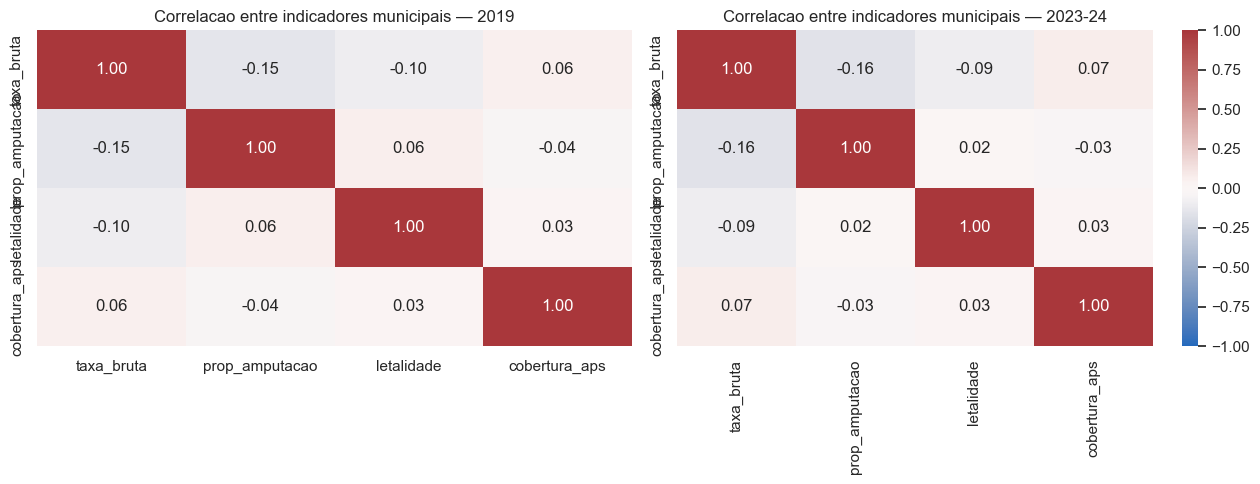

In [9]:
# Matriz de correlacao POR PERIODO. Uma matriz unica sobre 2019-2024 misturaria
# as duas metodologias de cobertura e produziria um coeficiente sem significado.
fig, eixos = plt.subplots(1, 2, figsize=(13, 5))
for ax, (rotulo, anos, _fonte) in zip(eixos, BLOCOS):
    bloco = (g[g['ano'].isin(anos)]
             .groupby('cod_municipio', as_index=False, observed=True)
             .agg(internacoes=('internacoes', 'sum'), populacao=('populacao', 'sum'),
                  amputacoes=('amputacoes', 'sum'), obitos=('obitos', 'sum'),
                  cobertura_aps=('cobertura_aps', 'mean')))
    bloco['taxa_bruta'] = 100000.0 * bloco['internacoes'] / bloco['populacao']
    bloco['prop_amputacao'] = bloco['amputacoes'] / bloco['internacoes']
    bloco['letalidade'] = bloco['obitos'] / bloco['internacoes']

    matriz = bloco[['taxa_bruta', 'prop_amputacao', 'letalidade', 'cobertura_aps']].corr()
    sns.heatmap(matriz, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1,
                ax=ax, cbar=(ax is eixos[-1]))
    ax.set_title(f'Correlacao entre indicadores municipais — {rotulo}')

fig.tight_layout(); fig.savefig('../docs/img/correlacao_componentes.png', dpi=150)


## 8. Municípios com maior proporção de amputação

A consulta 5 aplica o **critério principal** de elegibilidade do ranking do
ICVD: 20 internações somando 2019-2024 (`HAVING SUM(internacoes) >= 20` sobre a
gold inteira — ver `sql/consultas_duckdb.sql` e a Seção 3.5 de
`docs/03-modelagem.md`). O objetivo é o mesmo: não deixar municípios com poucos
casos dominarem o topo só por variância de números pequenos (ex.: 1 amputação
em 2 internações vira 50%).

**Não é idêntico ao ranking do ICVD**, e a diferença importa na hora de
comparar as duas listas: o ranking do ICVD (`03_indice_icvd.ipynb`, Seção 2)
acrescenta um segundo critério — pelo menos 5 internações em **cada** um dos
dois períodos (2019 e 2023-24) — e ainda exige cobertura de APS disponível.
Esta consulta é exploratória e olha o período inteiro de uma vez, então aplica
só o corte de volume total.

In [10]:
top_amputacao = con.execute(consultas[4]).df()
top_amputacao.head(10)

,cod_municipio,uf,regiao,internacoes,amputacoes,pct_amputacao
0,2901353,BA,Nordeste,25.0,13.0,52.00
1,2911253,BA,Nordeste,20.0,9.0,45.00
2,3126000,MG,Sudeste,25.0,11.0,44.00
3,2807402,SE,Nordeste,87.0,37.0,42.53
4,2928307,BA,Nordeste,22.0,9.0,40.91
5,3108107,MG,Sudeste,50.0,20.0,40.00
6,2901700,BA,Nordeste,20.0,8.0,40.00
7,4316956,RS,Sul,23.0,9.0,39.13
8,3155306,MG,Sudeste,26.0,10.0,38.46
9,2307908,CE,Nordeste,26.0,10.0,38.46


## 9. Verificação de sanidade

Antes de tirar qualquer conclusão da EDA, duas checagens automáticas:

- `verificar_denominadores` aponta linhas com internação registrada mas
  sem população correspondente (órfãs de join) — se houver muitas, os
  gráficos acima estão descrevendo um problema de pipeline, não um
  fenômeno real.
- `verificar_sanidade` levanta erro na primeira métrica fora do intervalo
  fisicamente possível. A função percorre a lista `LIMITES`
  (`src/diabetes_sus/validacao.py`) e **pula silenciosamente as colunas que não
  existem no quadro** — então, aplicada à camada gold, o que ela de fato checa
  aqui é `cobertura_aps` (entre 0% e 200%: a cobertura de ESF passa de 100% em
  municípios pequenos, mas acima de 200% é erro de unidade). As demais colunas
  da lista — `taxa_internacao_padronizada`, `prop_amputacao`, `letalidade` e
  `icvd` — não existem na gold, que é uma tabela de contagens: elas são
  calculadas em `03_indice_icvd.ipynb` e é lá que a mesma função as verifica.

Rodar as duas checagens aqui, na EDA, e não só no notebook do ICVD, é o que
garante que os gráficos desta análise já partem de uma gold sem órfãos de join
e sem cobertura de APS absurda.

In [11]:
from diabetes_sus.validacao import verificar_denominadores, verificar_sanidade
g = con.execute('SELECT * FROM gold').df()
orfaos = verificar_denominadores(g)
print(f'orfaos: {len(orfaos)} linhas')
verificar_sanidade(g)
print('sanidade OK')

orfaos: 0 linhas
sanidade OK


## Notas finais

Este notebook não foi executado localmente: ele depende de
`data/gold/municipio_ano.csv`, que só existe depois da etapa manual de
ingestão no Google Colab (notebook `01_ingestao_colab.ipynb`). Assim que o
CSV estiver disponível, rodar este notebook de ponta a ponta produz as seis
imagens em `docs/img/` referenciadas acima e os números que alimentam
`docs/04-conclusoes.md` — em especial o formato da distribuição municipal
(Seção 3), o contraste entre regiões antes/durante/depois da pandemia
(Seção 5) e a relação entre cobertura de APS e taxa de internação
(Seção 6).